In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from google.colab import drive
drive.mount('/content/drive')

!pip install xgboost catboost shap optuna mlflow imbalanced-learn pyBKT -q

import pandas as pd, numpy as np, random

DRIVE = '/content/drive/MyDrive/adaptive-learning/'

X_train = pd.read_csv(DRIVE + 'data/X_train.csv').values
y_train = pd.read_csv(DRIVE + 'data/y_train.csv').squeeze().values
X_val   = pd.read_csv(DRIVE + 'data/X_val.csv').values
y_val   = pd.read_csv(DRIVE + 'data/y_val.csv').squeeze().values

random.seed(42)
np.random.seed(42)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 15.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 87.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
import mlflow
mlflow.set_experiment('adaptive_learning_week2')


2026/04/28 08:31:00 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/28 08:31:00 INFO mlflow.store.db.utils: Updating database tables
2026/04/28 08:31:05 INFO mlflow.tracking.fluent: Experiment with name 'adaptive_learning_week2' does not exist. Creating a new experiment.


<Experiment: artifact_location='/content/mlruns/1', creation_time=1777365065561, experiment_id='1', last_update_time=1777365065561, lifecycle_stage='active', name='adaptive_learning_week2', tags={}, trace_location=None, workspace='default'>

In [6]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

def train_and_log(model, name, X_tr, y_tr, X_v, y_v):
    with mlflow.start_run(run_name=name):
        model.fit(X_tr, y_tr)
        preds = model.predict(X_v)
        acc = accuracy_score(y_v, preds)
        f1  = f1_score(y_v, preds, average='weighted')
        mlflow.log_params(model.get_params())
        mlflow.log_metric('val_accuracy', acc)
        mlflow.log_metric('val_f1_weighted', f1)
        print(f'{name:30s} | Acc: {acc:.4f} | F1: {f1:.4f}')
        print(classification_report(y_v, preds))
        return model, f1

dt,  dt_f1  = train_and_log(DecisionTreeClassifier(max_depth=5, random_state=42),
                             'DecisionTree_baseline', X_train, y_train, X_val, y_val)

rf,  rf_f1  = train_and_log(RandomForestClassifier(n_estimators=100, random_state=42),
                             'RandomForest_baseline', X_train, y_train, X_val, y_val)


DecisionTree_baseline          | Acc: 0.9200 | F1: 0.9205
              precision    recall  f1-score   support

    Advanced       0.88      1.00      0.93        21
  Developing       0.94      0.88      0.91        51
         Low       0.79      1.00      0.88        15
  Proficient       0.97      0.90      0.93        63

    accuracy                           0.92       150
   macro avg       0.89      0.95      0.91       150
weighted avg       0.93      0.92      0.92       150

RandomForest_baseline          | Acc: 0.9333 | F1: 0.9326
              precision    recall  f1-score   support

    Advanced       1.00      0.95      0.98        21
  Developing       0.92      0.90      0.91        51
         Low       0.92      0.80      0.86        15
  Proficient       0.93      0.98      0.95        63

    accuracy                           0.93       150
   macro avg       0.94      0.91      0.92       150
weighted avg       0.93      0.93      0.93       150



In [7]:
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)

results = []
models_to_train = [
    (XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss'), 'XGBoost_baseline'),
    (CatBoostClassifier(iterations=100, random_state=42, verbose=0),          'CatBoost_baseline'),
    (GradientBoostingClassifier(n_estimators=100, random_state=42),           'GBM_baseline'),
    (AdaBoostClassifier(n_estimators=100, random_state=42),                   'AdaBoost_baseline'),
    (KNeighborsClassifier(n_neighbors=5),                                     'KNN_baseline'),
    (MLPClassifier(hidden_layer_sizes=(100,50), random_state=42, max_iter=300),'MLP_baseline'),
]

for model, name in models_to_train:
    if 'XGB' in name:
        _, f1 = train_and_log(model, name, X_train, y_train_enc, X_val, y_val_enc)
    else:
        _, f1 = train_and_log(model, name, X_train, y_train, X_val, y_val)
    results.append({'model': name, 'f1': f1})


XGBoost_baseline               | Acc: 0.9667 | F1: 0.9666
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       0.96      0.94      0.95        51
           2       0.93      0.93      0.93        15
           3       0.97      0.98      0.98        63

    accuracy                           0.97       150
   macro avg       0.97      0.96      0.97       150
weighted avg       0.97      0.97      0.97       150

CatBoost_baseline              | Acc: 0.9267 | F1: 0.9264
              precision    recall  f1-score   support

    Advanced       1.00      0.95      0.98        21
  Developing       0.94      0.86      0.90        51
         Low       0.93      0.93      0.93        15
  Proficient       0.90      0.97      0.93        63

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.93      0.93      0.93       150

GBM_baseline  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


KNN_baseline                   | Acc: 0.9467 | F1: 0.9466
              precision    recall  f1-score   support

    Advanced       0.95      0.90      0.93        21
  Developing       0.98      0.92      0.95        51
         Low       0.88      1.00      0.94        15
  Proficient       0.94      0.97      0.95        63

    accuracy                           0.95       150
   macro avg       0.94      0.95      0.94       150
weighted avg       0.95      0.95      0.95       150

MLP_baseline                   | Acc: 0.9200 | F1: 0.9204
              precision    recall  f1-score   support

    Advanced       0.83      0.95      0.89        21
  Developing       1.00      0.86      0.93        51
         Low       0.94      1.00      0.97        15
  Proficient       0.89      0.94      0.91        63

    accuracy                           0.92       150
   macro avg       0.92      0.94      0.92       150
weighted avg       0.93      0.92      0.92       150



In [8]:
results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
print(results_df.to_string(index=False))


            model       f1
 XGBoost_baseline 0.966580
     KNN_baseline 0.946647
     GBM_baseline 0.939354
CatBoost_baseline 0.926370
     MLP_baseline 0.920352
AdaBoost_baseline 0.585925


In [9]:
import optuna
from sklearn.metrics import f1_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0, 1),
        'random_state': 42, 'eval_metric': 'mlogloss',
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train_enc,
              eval_set=[(X_val, y_val_enc)], verbose=False)
    preds = model.predict(X_val)
    return f1_score(y_val_enc, preds, average='weighted')

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_tuning')
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print('Best XGBoost F1:', study_xgb.best_value)
print('Best XGBoost params:', study_xgb.best_params)


  0%|          | 0/50 [00:00<?, ?it/s]

Best XGBoost F1: 0.9598083333333333
Best XGBoost params: {'n_estimators': 480, 'max_depth': 5, 'learning_rate': 0.07464691420157729, 'subsample': 0.647273196498032, 'colsample_bytree': 0.7860911239260948, 'min_child_weight': 3, 'gamma': 0.8374246590473955}


In [10]:
def rf_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'max_depth':         trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average='weighted')

study_rf = optuna.create_study(direction='maximize', study_name='rf_tuning')
study_rf.optimize(rf_objective, n_trials=50, show_progress_bar=True)
print('Best RF F1:', study_rf.best_value)
print('Best RF params:', study_rf.best_params)


  0%|          | 0/50 [00:00<?, ?it/s]

Best RF F1: 0.96
Best RF params: {'n_estimators': 353, 'max_depth': 30, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'log2'}


In [11]:

!pip install catboost -q

In [12]:
from catboost import CatBoostClassifier
import optuna
from sklearn.metrics import f1_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def catboost_objective(trial):
    params = {
        'iterations':        trial.suggest_int('iterations', 100, 1000),
        'depth':             trial.suggest_int('depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg':       trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count':      trial.suggest_int('border_count', 32, 255),
        'random_strength':   trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'random_seed': 42,
        'verbose': False,   # ← silences CatBoost's own output
        'eval_metric': 'TotalF1',
    }
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
    preds = model.predict(X_val)
    return f1_score(y_val, preds, average='weighted')


study_catboost = optuna.create_study(direction='maximize', study_name='catboost_tuning')
study_catboost.optimize(catboost_objective, n_trials=50, show_progress_bar=True)

print('Best CatBoost F1:', study_catboost.best_value)
print('Best CatBoost params:', study_catboost.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

Best CatBoost F1: 0.9800085169807304
Best CatBoost params: {'iterations': 262, 'depth': 3, 'learning_rate': 0.12148139080115952, 'l2_leaf_reg': 1.5869806735586058, 'bagging_temperature': 0.28502094043788123, 'border_count': 232, 'random_strength': 0.0050055082786440094}


In [13]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted']

tuned_models = {
    'XGBoost':      XGBClassifier(**study_xgb.best_params, random_state=42, eval_metric='mlogloss'),
    'RandomForest': RandomForestClassifier(**study_rf.best_params, random_state=42),
    'CatBoost':     CatBoostClassifier(**study_catboost.best_params, random_seed=42, verbose=False),
}

# Use y_train_enc for all models — XGBoost requires encoded integer labels
for name, model in tuned_models.items():
    results = cross_validate(model, X_train, y_train_enc, cv=cv,
                             scoring=scoring, return_train_score=False)
    print(f'\n{name}:')
    for metric in scoring:
        scores = results[f'test_{metric}']
        print(f'  {metric}: {scores.mean():.4f} +/- {scores.std():.4f}')


XGBoost:
  accuracy: 0.9769 +/- 0.0088
  f1_weighted: 0.9769 +/- 0.0088
  precision_weighted: 0.9774 +/- 0.0089
  recall_weighted: 0.9769 +/- 0.0088

RandomForest:
  accuracy: 0.9606 +/- 0.0087
  f1_weighted: 0.9606 +/- 0.0087
  precision_weighted: 0.9612 +/- 0.0088
  recall_weighted: 0.9606 +/- 0.0087

CatBoost:
  accuracy: 0.9786 +/- 0.0124
  f1_weighted: 0.9786 +/- 0.0124
  precision_weighted: 0.9790 +/- 0.0120
  recall_weighted: 0.9786 +/- 0.0124


In [14]:
# ── 12.2  Retrain final model on train + validation combined ──────────────────
import numpy as np
from catboost import CatBoostClassifier

X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train_enc, y_val_enc], axis=0)  # use encoded labels

final_model = CatBoostClassifier(**study_catboost.best_params, random_seed=42, verbose=False)
final_model.fit(X_trainval, y_trainval)
print('Final model trained on', len(X_trainval), 'samples')

Final model trained on 1318 samples


In [15]:
# ── 12.3  Evaluate ONCE on the test set ──────────────────────────────────────
import pandas as pd
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix)
from sklearn.preprocessing import LabelEncoder

X_test = pd.read_csv(DRIVE + 'data/X_test.csv').values
y_test_raw = pd.read_csv(DRIVE + 'data/y_test.csv').squeeze().values

# Encode y_test the same way you encoded y_train
le = LabelEncoder()
le.fit(y_train)           # fit on original training labels so classes match
y_test = le.transform(y_test_raw)

y_pred = final_model.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred, average='weighted')
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')

print(f'Accuracy:  {acc:.4f}')
print(f'F1:        {f1:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9667
F1:        0.9667
Precision: 0.9670
Recall:    0.9667

Confusion Matrix:
[[21  0  0  0]
 [ 0 49  2  0]
 [ 0  2 14  0]
 [ 1  0  0 61]]


In [21]:
# ── 12.4  Fairness metrics by subgroup ───────────────────────────────────────
X_test_orig = pd.read_csv(DRIVE + 'data/X_test_original.csv')

overall_f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Overall F1: {overall_f1:.4f}')

for col in ['gender', 'parental level of education']:
    print(f'\n--- Fairness by {col} ---')
    for group in X_test_orig[col].unique():
        mask = (X_test_orig[col] == group).values
        group_f1 = f1_score(y_test[mask], y_pred[mask], average='weighted')
        gap = overall_f1 - group_f1
        flag = '  ⚠️  FLAG — gap > 10pp' if gap > 0.10 else ''
        print(f'  {group}: F1 = {group_f1:.4f}  (gap: {gap:+.4f}){flag}')

Overall F1: 0.9667

--- Fairness by gender ---
  female: F1 = 0.9767  (gap: -0.0099)
  male: F1 = 0.9547  (gap: +0.0120)

--- Fairness by parental level of education ---
  high school: F1 = 0.9145  (gap: +0.0522)
  some college: F1 = 0.9827  (gap: -0.0159)
  associate's degree: F1 = 0.9729  (gap: -0.0062)
  some high school: F1 = 1.0000  (gap: -0.0333)
  master's degree: F1 = 1.0000  (gap: -0.0333)
  bachelor's degree: F1 = 0.9285  (gap: +0.0382)


In [22]:
# ── Save the model ────────────────────────────────────────────────────────────
import joblib
joblib.dump(final_model, DRIVE + 'models/adaptive_model.joblib')
print('Model saved successfully.')

Model saved successfully.


In [19]:
# Print the column names with their index numbers
columns = pd.read_csv(DRIVE + 'data/X_test.csv').columns.tolist()
for i, name in enumerate(columns):
    print(f'{i}: {name}')

0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6
7: 7
8: 8
9: 9
10: 10
11: 11
12: 12
13: 13
14: 14


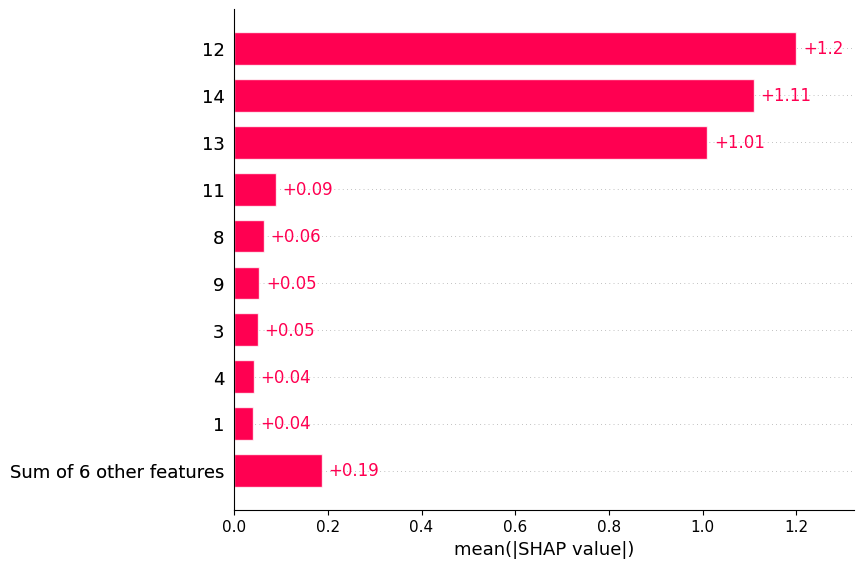

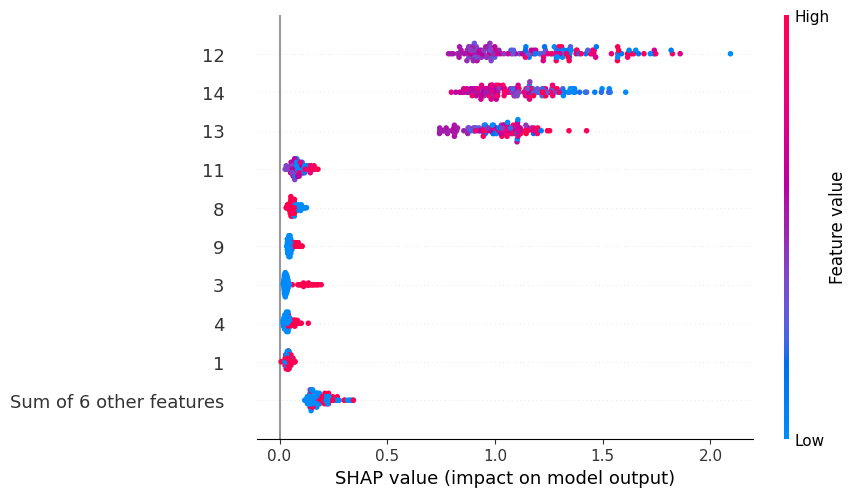

In [20]:
# Force feature names onto the SHAP values using an Explanation object
X_test_df = pd.read_csv(DRIVE + 'data/X_test.csv')
feature_names = X_test_df.columns.tolist()

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_df.values)
shap_values_mean = np.abs(shap_values).mean(axis=2)

# Wrap in a SHAP Explanation object so names are guaranteed to show
explanation = shap.Explanation(
    values=shap_values_mean,
    data=X_test_df.values,
    feature_names=feature_names
)

plt.figure(figsize=(10, 6))
shap.plots.bar(explanation, show=False)
plt.savefig(DRIVE + 'data/shap_global_bar.png', bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 8))
shap.plots.beeswarm(explanation, show=False)
plt.savefig(DRIVE + 'data/shap_beeswarm.png', bbox_inches='tight')
plt.show()

In [28]:
!pip install pyBKT -q

from pyBKT.models import Model
print('pyBKT installed and imported successfully.')


pyBKT installed and imported successfully.


In [29]:
bkt_config = {
  'mathematics_algebra': {
    'prior': 0.15,
    'learns': 0.30,
    'guesses': 0.20,
    'slips': 0.10,
    'mastery_threshold': 0.95
  },
  'mathematics_geometry': {
    'prior': 0.10,
    'learns': 0.25,
    'guesses': 0.20,
    'slips': 0.10,
    'mastery_threshold': 0.95
  },
  'science_biology': {
    'prior': 0.20,
    'learns': 0.35,
    'guesses': 0.25,
    'slips': 0.12,
    'mastery_threshold': 0.95
  },
  'english_comprehension': {
    'prior': 0.25,
    'learns': 0.30,
    'guesses': 0.20,
    'slips': 0.10,
    'mastery_threshold': 0.95
  },
  'social_studies': {
    'prior': 0.20,
    'learns': 0.35,
    'guesses': 0.25,
    'slips': 0.12,
    'mastery_threshold': 0.95
  }
}

import json
with open(DRIVE + 'models/bkt_config.json', 'w') as f:
    json.dump(bkt_config, f, indent=2)
print('BKT configuration saved.')


BKT configuration saved.


In [30]:
def bkt_update(p_learned, p_transit, p_guess, p_slip, is_correct):
    """
    Update BKT mastery probability after one student response.
    Args:
        p_learned: Current P(L_n) — probability student knows the skill
        p_transit: P(T) — probability of learning from one opportunity
        p_guess:   P(G) — probability of correct response without knowledge
        p_slip:    P(S) — probability of incorrect response despite knowledge
        is_correct: True if student answered correctly, False otherwise
    Returns:
        Updated P(L_{n+1})
    """
    if is_correct:
        p_obs_given_learned  = 1 - p_slip
        p_obs_given_notlearned = p_guess
    else:
        p_obs_given_learned  = p_slip
        p_obs_given_notlearned = 1 - p_guess

    # Bayes theorem — posterior probability given this observation
    p_learned_given_obs = (p_obs_given_learned * p_learned) / (
        p_obs_given_learned * p_learned +
        p_obs_given_notlearned * (1 - p_learned)
    )

    # Update for learning opportunity
    p_new = p_learned_given_obs + (1 - p_learned_given_obs) * p_transit
    return p_new

# Test the formula with known values
p = 0.15  # starting probability (P(L0))
responses = [True, False, True, True, True]  # simulate answer sequence

print('BKT trace:')
for i, correct in enumerate(responses):
    p = bkt_update(p, 0.30, 0.20, 0.10, correct)
    print(f'  After Q{i+1} (correct={correct}): P(L) = {p:.4f}')

print(f'Mastery reached: {p >= 0.95}')


BKT trace:
  After Q1 (correct=True): P(L) = 0.6098
  After Q2 (correct=False): P(L) = 0.4144
  After Q3 (correct=True): P(L) = 0.8327
  After Q4 (correct=True): P(L) = 0.9701
  After Q5 (correct=True): P(L) = 0.9952
Mastery reached: True
